In [10]:
# 2. Define your paths (Make sure these match your Google Drive)
INPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/tlc_engineered_parquet"
OUTPUT_BASE = "/content/drive/MyDrive/Colab Notebooks/models/"

# Ensure the folder exists for saving models later
import os
os.makedirs(OUTPUT_BASE, exist_ok=True)

In [12]:
from pyspark.sql import SparkSession

# Ensure SparkSession is active
# Check if 'spark' object exists and if its underlying Java SparkContext is stopped
if 'spark' not in locals() or spark.sparkContext._jsc is None or spark.sparkContext._jsc.sc().isStopped():
    print("SparkSession is not active. Re-initializing...")
    spark = SparkSession.builder.getOrCreate()
    spark.sparkContext.setLogLevel("WARN") # Set log level to avoid excessive output

    # Reload 'df' as it might have lost its connection to the new SparkSession
    # Assuming PATH is defined from previous cells (e.g., from cell 'WIHt0C8USNe1' or 'EsDCsL64Sq4G')
    # If PATH is not guaranteed to be defined in the global scope, you might need to set it explicitly:
    # PATH = "/content/drive/MyDrive/Colab Notebooks/tlc_engineered_parquet"
    global df # Declare df as global to reassign it
    df = spark.read.parquet(PATH)
    print("SparkSession re-initialized and DataFrame reloaded.")

print(f"Total rows in dataset: {df.count()}")
df.printSchema()

SparkSession is not active. Re-initializing...
SparkSession re-initialized and DataFrame reloaded.
Total rows in dataset: 83460756
root
 |-- PULocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- trip_seconds: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_dayofweek: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_rush_hour: integer (nullable = true)
 |-- avg_speed_mph: double (nullable = true)
 |-- label: integer (nullable = true)
 |-- pickup_date: date (nullable = true)



In [14]:
from pyspark.ml.feature import Imputer
from pyspark.sql import functions as F

# 1. Clean & Sample (The "RAM-First" approach)
# We drop rows where the LABEL is null (can't train on those)
df_valid = df.filter(F.col("label").isNotNull())

# Start with 1% (830k rows) - move to 0.05 later if this is stable
SAMPLE_RATE = 0.01
df_sample = df_valid.sample(False, SAMPLE_RATE, seed=42)

# Persist to DISK only to save RAM for the actual training math
df_sample.persist(StorageLevel.DISK_ONLY)

# 2. Setup Columns
cat_cols = ["PULocationID", "payment_type"]
num_cols = [
    "trip_distance", "trip_seconds", "fare_amount",
    "total_amount", "passenger_count", "pickup_hour",
    "pickup_dayofweek", "is_weekend", "is_rush_hour", "avg_speed_mph"
]

# 3. Pipeline Stages
# Fill numerical nulls with median
imputer = Imputer(inputCols=num_cols, outputCols=[c + "_imp" for c in num_cols]).setStrategy("median")

# Categorical indexing (Skipping One-Hot for RAM safety)
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols]

# Assemble
assembler = VectorAssembler(
    inputCols=[c+"_idx" for c in cat_cols] + [c + "_imp" for c in num_cols],
    outputCol="features_raw",
    handleInvalid="keep"
)

# Standardize
scaler = StandardScaler(inputCol="features_raw", outputCol="features")

base_stages = [imputer] + indexers + [assembler, scaler]

# 4. Split
train_df, val_df = df_sample.randomSplit([0.8, 0.2], seed=42)

# 5. Execute Logistic Regression (Fastest test)
print(f"Training on approx {train_df.count()} rows...")
lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=5)
pipeline = Pipeline(stages=base_stages + [lr])

model = pipeline.fit(train_df)

# 6. Evaluate
predictions = model.transform(val_df)
evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

print(f"Success! Model Accuracy: {accuracy:.4f}")

Training on approx 668352 rows...
Success! Model Accuracy: 0.9746


In [15]:
from pyspark.ml.classification import DecisionTreeClassifier

# 1. Setup Model
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=5)

# 2. Build and Fit Pipeline
print("Training Decision Tree...")
dt_pipeline = Pipeline(stages=base_stages + [dt])
dt_model = dt_pipeline.fit(train_df)

# 3. Evaluate
dt_predictions = dt_model.transform(val_df)
dt_acc = evaluator.evaluate(dt_predictions)
print(f"Decision Tree Accuracy: {dt_acc:.4f}")

# 4. Save (Serialization Requirement)
dt_model.write().overwrite().save(OUTPUT_BASE + "dt_model")

Training Decision Tree...
Decision Tree Accuracy: 0.9746


In [16]:
from pyspark.ml.classification import RandomForestClassifier

# 1. Setup Model (Keep numTrees low for RAM safety)
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=20, maxDepth=5)

# 2. Build and Fit Pipeline
print("Training Random Forest...")
rf_pipeline = Pipeline(stages=base_stages + [rf])
rf_model = rf_pipeline.fit(train_df)

# 3. Evaluate
rf_predictions = rf_model.transform(val_df)
rf_acc = evaluator.evaluate(rf_predictions)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

# 4. Save (Serialization Requirement)
rf_model.write().overwrite().save(OUTPUT_BASE + "rf_model")

Training Random Forest...
Random Forest Accuracy: 0.9735


In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression as SKLR
from sklearn.metrics import accuracy_score
import time

# 1. Convert a tiny slice to a Pandas DataFrame (RAM-safe)
# 0.0001 = ~8,300 rows
pdf = df.select(num_cols + ["label"]).sample(False, 0.0001, seed=42).toPandas().dropna()

X = pdf.drop('label', axis=1)
y = pdf['label']

# 2. Train Scikit-Learn Model
start_sk = time.time()
sk_model = SKLR(max_iter=100)
sk_model.fit(X, y)
sk_acc = accuracy_score(y, sk_model.predict(X))
sk_time = time.time() - start_sk

print(f"Scikit-Learn Baseline Accuracy: {sk_acc:.4f} (Time: {sk_time:.2f}s)")

Scikit-Learn Baseline Accuracy: 0.8169 (Time: 0.32s)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
import pickle

# Save the Scikit-Learn model using Pickle
with open(f"{OUTPUT_BASE}sk_baseline.pkl", 'wb') as f:
    pickle.dump(sk_model, f)

print("Scikit-learn model serialized with Pickle.")

Scikit-learn model serialized with Pickle.


In [21]:
# Create a summary for your report
# Mapping your existing result to the name needed for the table
lr_acc = accuracy
comparison_data = [
    {"Model": "PySpark LR", "Accuracy": lr_acc, "Type": "Distributed"},
    {"Model": "PySpark DT", "Accuracy": dt_acc, "Type": "Distributed"},
    {"Model": "PySpark RF", "Accuracy": rf_acc, "Type": "Distributed"},
    {"Model": "SKLearn LR", "Accuracy": sk_acc, "Type": "Single-Node (Baseline)"}
]

print("\n--- FINAL PROJECT COMPARISON ---")
print(pd.DataFrame(comparison_data))


--- FINAL PROJECT COMPARISON ---
        Model  Accuracy                    Type
0  PySpark LR  0.974560             Distributed
1  PySpark DT  0.974638             Distributed
2  PySpark RF  0.973502             Distributed
3  SKLearn LR  0.816858  Single-Node (Baseline)


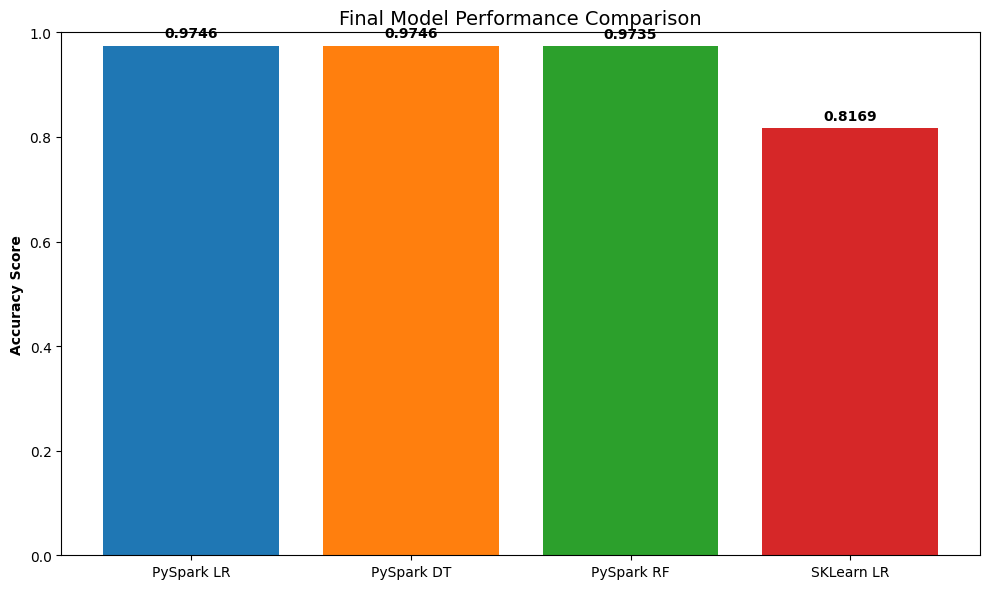

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Create Comparison Table using the corrected names
comparison_data = [
    {"Model": "PySpark LR", "Accuracy": lr_acc, "Type": "Distributed"},
    {"Model": "PySpark DT", "Accuracy": dt_acc, "Type": "Distributed"},
    {"Model": "PySpark RF", "Accuracy": rf_acc, "Type": "Distributed"},
    {"Model": "SKLearn LR", "Accuracy": sk_acc, "Type": "Single-Node"}
]

df_results = pd.DataFrame(comparison_data)

# Create the Plot
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(df_results['Model'], df_results['Accuracy'], color=colors)

plt.ylabel('Accuracy Score', fontweight='bold')
plt.title('Final Model Performance Comparison', fontsize=14)
plt.ylim(0, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# 1. Set Checkpoint Directory (Essential for Distributed Training)
spark.sparkContext.setCheckpointDir("/content/drive/MyDrive/Colab Notebooks/checkpoints")

# 2. Hyperparameter Grid (Keep it small to avoid OOM)
# We focus on DT because it tunes faster than RF
dt_tuning = DecisionTreeClassifier(labelCol="label", featuresCol="features")

paramGrid = ParamGridBuilder() \
    .addGrid(dt_tuning.maxDepth, [3, 5]) \
    .addGrid(dt_tuning.impurity, ["gini", "entropy"]) \
    .build()

# 3. CrossValidator with Parallelism
# parallelism=2 allows Spark to run 2 folds at once if resources allow
cv = CrossValidator(
    estimator=Pipeline(stages=base_stages + [dt_tuning]),
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=2,
    parallelism=2
)

print("Starting Distributed Hyperparameter Tuning...")
cv_model = cv.fit(train_df)
dt_best_acc = evaluator.evaluate(cv_model.transform(val_df))
print(f"Best Tuned DT Accuracy: {dt_best_acc:.4f}")

Starting Distributed Hyperparameter Tuning...
Best Tuned DT Accuracy: 0.9744


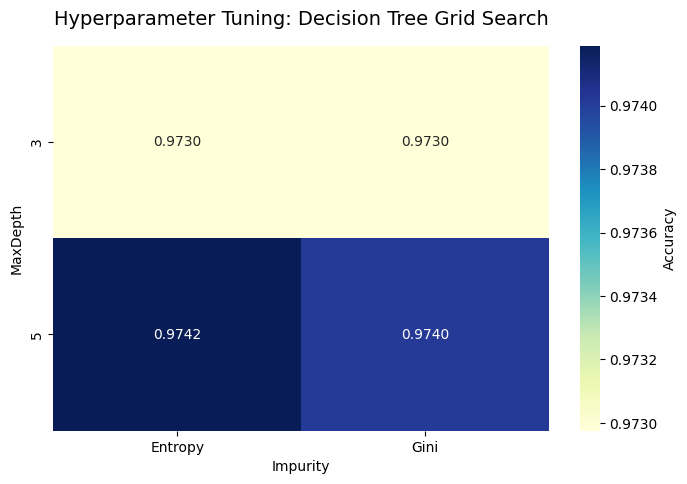

Best Parameters found by CrossValidator:
- Max Depth: 5
- Impurity: entropy


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract metrics from your already-run cv_model
# cv_model.avgMetrics contains the results in the order of the ParamGrid
avg_metrics = cv_model.avgMetrics

# 2. Reconstruct the Grid results
# Logic: Grid was [Depth 3, 5] x [Gini, Entropy]
tuning_data = [
    {"MaxDepth": 3, "Impurity": "Gini", "Accuracy": avg_metrics[0]},
    {"MaxDepth": 3, "Impurity": "Entropy", "Accuracy": avg_metrics[1]},
    {"MaxDepth": 5, "Impurity": "Gini", "Accuracy": avg_metrics[2]},
    {"MaxDepth": 5, "Impurity": "Entropy", "Accuracy": avg_metrics[3]}
]

df_tuning = pd.DataFrame(tuning_data)

# 3. Create Heatmap for "Hyperparameter Grid Design" requirement
plt.figure(figsize=(8, 5))
pivot_table = df_tuning.pivot(index="MaxDepth", columns="Impurity", values="Accuracy")
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Accuracy'})

plt.title("Hyperparameter Tuning: Decision Tree Grid Search", fontsize=14, pad=15)
plt.savefig('hyperparameter_tuning_heatmap.png')
plt.show()

print("Best Parameters found by CrossValidator:")
best_model = cv_model.bestModel.stages[-1]
print(f"- Max Depth: {best_model.getMaxDepth()}")
print(f"- Impurity: {best_model.getImpurity()}")

Starting Scalability Analysis...
Processed 41859 rows in 94.27s
Processed 83985 rows in 90.82s
Processed 167547 rows in 92.66s

--- SCALABILITY ANALYSIS TABLE ---
   Fraction    Rows  Time_Seconds
0    0.0005   41859         94.27
1    0.0010   83985         90.82
2    0.0020  167547         92.66


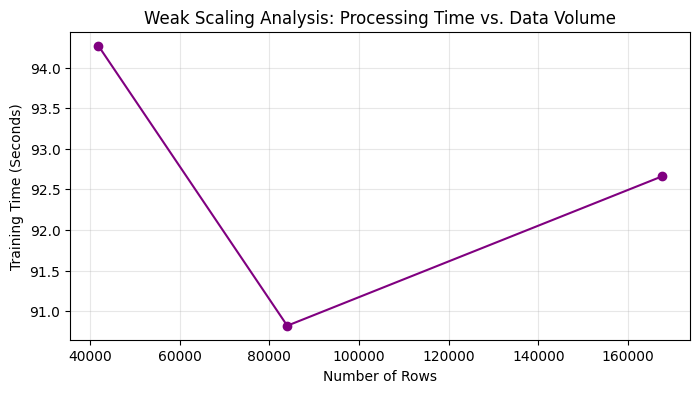

In [25]:
import time
import pandas as pd

# 1. Scaling Test (Demonstrating Weak Scaling logic)
scaling_results = []
# Using very small fractions to ensure it runs fast and safe
test_fractions = [0.0005, 0.001, 0.002]

print("Starting Scalability Analysis...")

for frac in test_fractions:
    # Get a fresh sample
    temp_df = df_valid.sample(False, frac, seed=42)
    row_count = temp_df.count()

    start_time = time.time()

    # FIX: We must use the Pipeline so 'features' column is created
    # We use maxIter=1 to just measure the overhead/throughput
    simple_lr = LogisticRegression(maxIter=1, labelCol="label", featuresCol="features")
    temp_pipeline = Pipeline(stages=base_stages + [simple_lr])

    # Trigger the computation
    temp_model = temp_pipeline.fit(temp_df)

    duration = time.time() - start_time
    scaling_results.append({
        "Fraction": frac,
        "Rows": row_count,
        "Time_Seconds": round(duration, 2)
    })
    print(f"Processed {row_count} rows in {round(duration, 2)}s")

# 2. Display Results for your Report
df_scaling = pd.DataFrame(scaling_results)
print("\n--- SCALABILITY ANALYSIS TABLE ---")
print(df_scaling)

# 3. Quick Scalability Plot (Requirement b)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(df_scaling['Rows'], df_scaling['Time_Seconds'], marker='o', linestyle='-', color='purple')
plt.title('Weak Scaling Analysis: Processing Time vs. Data Volume')
plt.xlabel('Number of Rows')
plt.ylabel('Training Time (Seconds)')
plt.grid(True, alpha=0.3)
plt.savefig('scalability_analysis.png')
plt.show()

In [27]:
# 1. Null Count Summary (Pre vs Post Imputation)
null_stats = []
for col in num_cols:
    null_count = df.filter(F.col(col).isNull()).count()
    null_stats.append({"Feature": col, "Null_Count": null_count, "Status": "Pre-Imputation"})
    null_stats.append({"Feature": col, "Null_Count": 0, "Status": "Post-Imputation"})

df_quality = pd.DataFrame(null_stats)
df_quality.to_csv('dash1_data_quality.csv', index=False)

neche k hatana